In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from pathlib import Path
import sys

from mujoco_irb120.common.helper_fns import *
# import mujoco_irb120.common.helper_fns as helpers

## Formulating New 'Squash and Pull' Tipping Paradigm

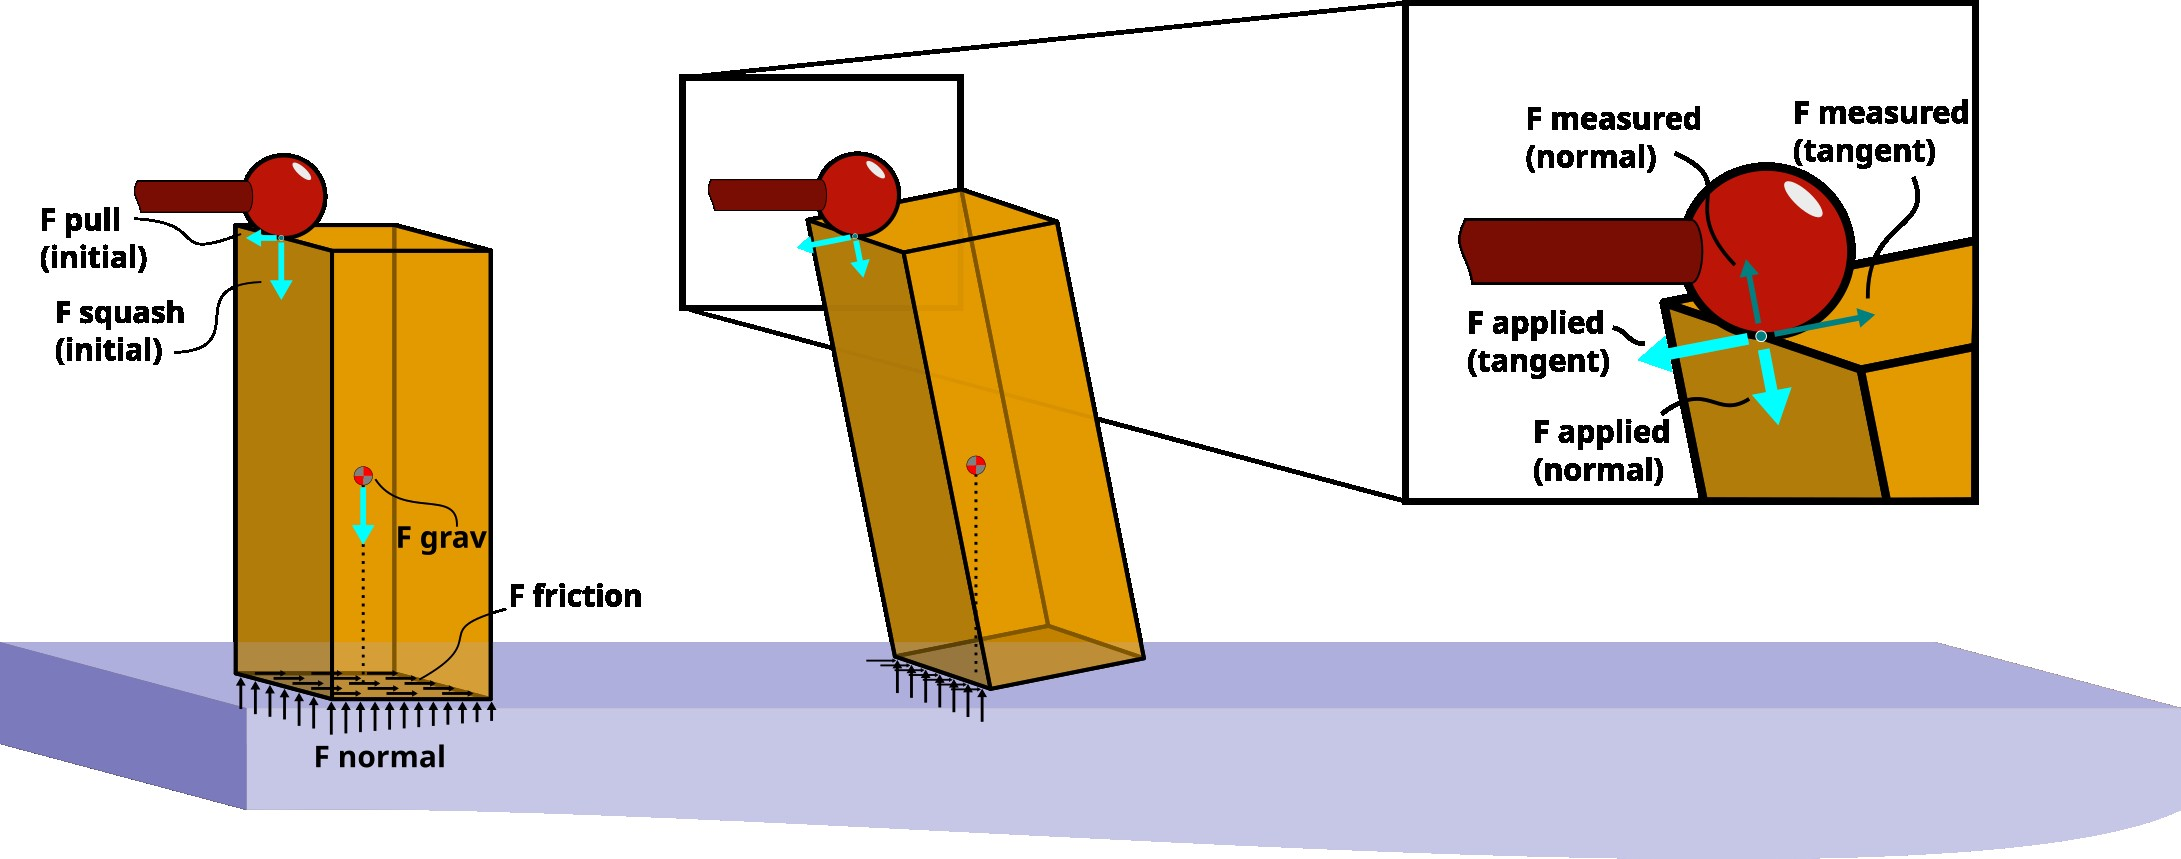

Given the above image, we can write the Force and Moment balance equations under a quasistatic regime.

$$
F_\text{applied} + F_\text{grav}+F_\text{fric}+F_\text{normal} = 0
$$

$$
(p_\text{finger}\times F_\text{applied}) + (p_\text{c}\times F_\text{grav}) + (p_\text{fric}\times F_\text{fric}) + (p_\text{normal}\times F_\text{normal})= 0
$$

For *Object Frame* $\{O\}$ located at tipping edge, we can say:
$$
\cancel{p_\text{fric}}\,0 \qquad \cancel{p_\text{normal}\,0}
$$


### Transforming measured wrenches to body wrenches
Of course, our F/T sensor is mounted 'behind' the finger. So to satisfy the wrench balance, we must perform the **adjoint transformation**.
Given: $\{O\} \,, \{B\} \,, \{S\}$ Object, (robot) Base, and Sensor frames, respectively:

$$
w^O_\text{app} = Ad_{T_{o/s}} \, w^S_\text{meas}
$$

$$
\begin{bmatrix}
f^O_\text{app} \\ \tau^O_\text{app}
\end{bmatrix} 
=
\begin{bmatrix}
R^O_S & 0 \\ \left[p^O_{s/o}\right]_\times R^O_S & R^O_S
\end{bmatrix}
\,
\begin{bmatrix}
f^S_\text{meas} \\ \tau^S_\text{meas}
\end{bmatrix}
$$
where:
- $R^O_S$ is rotation from Sensor to Object frame.
- $p^O_{s/o}$ is translation vector from Pivot to Sensor origin in the Object frame.
- $\left[\cdot\right]_\times$ is the skew-symmetric matrix, recall equivalent to cross product.


## Equations of (quasistatic) motion:
$$
w^O_\text{applied} + w^O_\text{gravity} + w^O_\text{ground} = 0
$$
Decomposed with frames: $O$ object, $S$ sensor, & $B$ robot base:
$$
^O\mathbf{w}_{app} = \begin{bmatrix} ^O\mathbf{R}_S & \mathbf{0} \\ [^O\mathbf{p}_{s/o}]_\times ^O\mathbf{R}_S & ^O\mathbf{R}_S \end{bmatrix} \begin{bmatrix} ^S\mathbf{f}_{meas} \\ ^S\tau_{meas} \end{bmatrix}
$$
$$
^O\mathbf{w}_{grav} = \begin{bmatrix} ^O\mathbf{f}_{grav} \\ ^S\tau_{grav} \end{bmatrix}
=
\begin{bmatrix} m  ^O\mathbf{g}(\theta) \\ ^O\mathbf{p}_{com} \times (m  ^O\mathbf{g}(\theta)) \end{bmatrix}
$$
$$
^O\mathbf{w}_{ground} = \begin{bmatrix} ^O\mathbf{f}_{ground} \\ 0_{3\times 1} \end{bmatrix}
=
\begin{bmatrix} 
\mathbf{f}_{t,x} \\ \mathbf{f}_{t,y} \\ \mathbf{N}_t \\ 0_{3\times 1}
\end{bmatrix}
$$
So we have 6 Equations, 3 from $F$ and 3 from $\tau$
And we have 6 unknowns, $\{m\,, x_c\,, y_c\,, z_c\,, \mu_f \text{(finger)}\,, \mu_t \text{(table)} \}$

Take the 6 unknowns as our parameter vector: $x = \left[m, x_c, y_c, z_c, \mu_f, \mu_t \right]$
1. Solve for CoM and mass with least squares, as usual
2. Solve for friction using **limit of stability** approximation (since no sliding)
$$
\begin{matrix}
\mu_f \approx \frac{||\text{proj}_{tan}(^o\mathbf{f}_{app})||}{\text{proj}_{norm}(^o\mathbf{f}_{app})} &&&&& \mu_t \approx \frac{\sqrt{f^2_{tx}+f^2_{ty}}}{N_t}
\end{matrix}
$$
$$

$$

## The Python way to write this is:

In [14]:
theta_B = np.deg2rad(np.array([0.0, -1.0, 0.0]))              # rotation in e_hat_B direction (in space/robot/table/world frame)
# e_hat_B = np.array([0.0, -1.0, 0.0])    # we CANNOT define as -y because it breaks math later on... just roll with the punches.
R_B = rotvec_to_rot(theta_B)   # rotation matrix for pulling about vertical axis

## Constants
finger_length = 0.1                     # simple distance from contact point to sensor flange
object_height = 0.2                     # height of object's top surface where finger acts

## Vectors
g_B = np.array([0.0, 0.0, -9.81])       # gravity vector (in world frame)

p_finger_O = np.array([0.0, 0.0, object_height]) # position of finger contact point (in object frame)
p_S_O = p_finger_O + np.array([-finger_length, 0.0, 0.0])                  # vector from object to sensor flange (in object frame)

# rob_v_B = np.array([-1.0, 0.0, 0.0])    # velocity of robot (in world frame)

## Adjoint from sensor frame to object frame, since we want to transform wrenches from {S} to {O}
T_S_O = np.eye(4)
T_S_O[:3,:3] = R_B.T
T_S_O[:3,3] = p_S_O
adT_S_O = Adjoint(T_S_O) # This way, as the object rotates, the applied/measured wrench rotates opposite so that it remains 'constant' in the object frame. TODO: verify


# Decompose ground reaction into normal/tangent components using table normal
# n_table_B = np.array([0.0, 0.0, 1.0])     # table normal (in world frame)
# n_table_O = R_B.T @ n_table_B                     # same normal expressed in object frame
# n_table_O = n_table_O / np.linalg.norm(n_table_O)

## Unknowns
p_c_O = np.array([0.05, 0.0, object_height/2]) # UNKNOWN TO US, CoM (in object frame)
mass = 1.0                              # UNKNOWN TO US, mass of object
# mu_table = 0.5                          # UNKNOWN TO US, coefficient of friction at TABLE contact
# f_fric_scalar = mu_table * mass * np.linalg.norm(g_B)                     # friction at table (scalar) (in object frame)
    # A few ways to 'determine' or approximate friction direction:
    # 1. Assume measured force is same as table friction (since rigid body)
    # 2. Assume friction orthogonal to tipping axis
    # 3. Practically, we know the robot's velocity, so assume friction opposes that with no z-component.
# f_fric_S = rob_v_B/np.linalg.norm(rob_v_B) * f_fric_scalar
# f_fric_O = R_B.T @ f_fric_S

In [15]:
def model(fz, R_B, g_B, p_finger_O, p_S_O, adT_S_O, p_c_O, mass):
    ## CONSTRUCT APPLIED WRENCH
    f_meas_S = np.array([0.0, 0.0, fz])                                    # measured force in sensor frame (I modified Fx until residuals dissapeared)
    tau_meas_S = np.array(np.cross(p_S_O, f_meas_S))                        # pseudo measured torque in sensor frame
    w_meas_S = np.hstack((f_meas_S, tau_meas_S)).round(3)
    # print("Measured wrench in sensor frame:", w_meas_S, np.shape(w_meas_S))

    w_meas_O = np.array([adT_S_O @ w_meas_S]).flatten().round(3)
    # print("Measured wrench in object frame:", w_meas_O, np.shape(w_meas_O))

    # IMPORTANT SIGN: sensor usually reports force ON sensor by object.
    f_app_O = -w_meas_O[:3]                                                 # Force applied ON object by finger is opposite.
    t_app_O = np.cross(p_finger_O, f_app_O)                                 # Torque applied ON object by finger is r_o_to_finger x f_app
    w_app_O = np.hstack((f_app_O, t_app_O)).round(3)
    # print("Applied wrench on object frame:", w_app_O, np.shape(w_app_O))

    # *********************************************************************************************

    # CONSTRUCT GRAVITY WRENCH
    g_O = R_B.T @ g_B                       # Rotate by -theta_B to get gravity vector (in object frame)
    f_grav_O = mass * g_O
    tau_grav_O = np.cross(p_c_O, f_grav_O)
    w_grav_O = np.hstack((f_grav_O, tau_grav_O)).round(3)
    # print("\nGravity wrench in object frame: ", w_grav_O, np.shape(w_grav_O))

    # *********************************************************************************************

    # CONSTRUCT GROUND REACTION WRENCH (from quasistatic force balance: w_app + w_grav + w_ground = 0)
    f_ground_O = -(w_app_O[:3] + w_grav_O[:3])
    # print("\nGround reaction force in object frame:", f_ground_O)

    # N_scalar = np.dot(f_ground_O, n_table_O)
    # f_normal_O = N_scalar * n_table_O
    # f_tangent_O = f_ground_O - f_normal_O

    # print("Table normal in object frame:", np.round(n_table_O, 3))
    # print("Normal magnitude N:", np.round(N_scalar, 3))
    # print("Normal force vector:", np.round(f_normal_O, 3))
    # print("Tangential force vector:", np.round(f_tangent_O, 3))

    # If origin is at tipping edge, ground-reaction MOMENT at origin is zero by construction.
    w_ground_O = np.hstack((f_ground_O, np.zeros(3)))
    # print("\nGround reaction wrench in object frame:", w_ground_O, np.shape(w_ground_O))

    # Residual check (should be ~0):
    residual = w_app_O + w_grav_O + w_ground_O
    print("\nWrench balance residual:", np.round(residual, 6), "(should be zero)")

    return residual

## Inverse:
#### Find downwards applied force required to yield tipping and not sliding
(i.e., maintain quasistatic wrench balance by modulating F_app)

In [ ]:
# Now let's try modulating F_z and determining the F_x required.
# OG setup: fx=2.455, fz=0.5 theta=0.___
for fz in range(0, 1000, 100):
    print("\n\n--- Testing with Fz =", fz, "---")
    residual = model(fz, R_B, g_B, p_finger_O, p_S_O, adT_S_O, p_c_O, mass)



--- Testing with Fz = 0 ---

Wrench balance residual: [0.    0.    0.    0.    0.473 0.   ] (should be zero)


--- Testing with Fz = 100 ---

Wrench balance residual: [0.    0.    0.    0.    0.124 0.   ] (should be zero)


--- Testing with Fz = 200 ---

Wrench balance residual: [ 0.     0.     0.     0.    -0.225  0.   ] (should be zero)


--- Testing with Fz = 300 ---

Wrench balance residual: [ 0.     0.     0.     0.    -0.574  0.   ] (should be zero)


--- Testing with Fz = 400 ---

Wrench balance residual: [ 0.     0.     0.     0.    -0.923  0.   ] (should be zero)


--- Testing with Fz = 500 ---

Wrench balance residual: [ 0.     0.     0.     0.    -1.272  0.   ] (should be zero)


--- Testing with Fz = 600 ---

Wrench balance residual: [ 0.     0.     0.     0.    -1.621  0.   ] (should be zero)


--- Testing with Fz = 700 ---

Wrench balance residual: [ 0.    0.    0.    0.   -1.97  0.  ] (should be zero)


--- Testing with Fz = 800 ---

Wrench balance residual: [ 0.     0

In [ ]:
# Robust formulation sketch: stack many samples with shared object parameters.
# Shared params: [m, pcx, pcy, pcz, mu_t]
# Per-sample nuisance params: [N_t_i, lambda_t_i]

def stacked_residual_shared_params(
    x_shared,
    fz_series, R_series,
    g_B, p_finger_O, p_S_O, adT_series,
    pull_dir_B=np.array([-1.0, 0.0, 0.0]),
    penalty_weight=10.0,
    ):
    m, pcx, pcy, pcz, mu_t = x_shared
    p_c_O = np.array([pcx, pcy, pcz])

    # Closed-form guess per sample from force balance projection (fast inner approximation).
    # N and lambda are then constrained by friction penalties inside residual.
    residuals = []
    for i in range(len(fz_series)):
        R_B_i = R_series[i]
        adT_i = adT_series[i]

        # Start from an unconstrained least-squares split for table reaction components.
        # Here we seed N/lambda from equilibrium using current shared params.
        f_meas_S = np.array([0.0, 0.0, fz_series[i]])
        tau_meas_S = np.cross(p_S_O, f_meas_S)
        w_meas_O = adT_i @ np.hstack((f_meas_S, tau_meas_S))
        f_app_O = -w_meas_O[:3]

        g_O_i = R_B_i.T @ g_B
        f_grav_O = m * g_O_i
        f_needed = -(f_app_O + f_grav_O)

        n_table_O = _unit(R_B_i.T @ np.array([0.0, 0.0, 1.0]))
        pull_dir_O = R_B_i.T @ _unit(pull_dir_B)
        t_hat_O = _unit(pull_dir_O - np.dot(pull_dir_O, n_table_O) * n_table_O)

        N_i = np.dot(f_needed, n_table_O)
        lam_i = np.dot(f_needed, t_hat_O)

        x_i = np.array([m, p_c_O[0], p_c_O[1], p_c_O[2], mu_t, N_i, lam_i])
        res_i, _ = forward_model_with_unknown_ground(
            fz=fz_series[i],
            x=x_i,
            R_B=R_B_i,
            g_B=g_B,
            p_finger_O=p_finger_O,
            p_S_O=p_S_O,
            adT_S_O=adT_i,
            pull_dir_B=pull_dir_B,
            penalty_weight=penalty_weight,
            verbose=False,
        )
        residuals.append(res_i)

    return np.hstack(residuals)

# Example usage (when you have a time history):
if False:
    # Build series arrays from data history.
    fz_series = np.clip(-f_meas_hist[:, 2], 1e-3, None)  # example mapping; adjust sign by your sensor convention
    R_series = [R_B for _ in range(len(fz_series))]      # replace with per-sample orientation
    adT_series = [adT_S_O for _ in range(len(fz_series))]# replace with per-sample Adjoint if varying

    x0_shared = np.array([1.0, 0.05, 0.0, 0.10, 0.5])    # [m, pcx, pcy, pcz, mu_t]
    lb = np.array([1e-4, -np.inf, -np.inf, 0.0, 0.0])
    ub = np.array([np.inf, np.inf, np.inf, np.inf, 2.0])

    result_shared = sp.optimize.least_squares(
        lambda x: stacked_residual_shared_params(
            x, fz_series, R_series, g_B, p_finger_O, p_S_O, adT_series
        ),
        x0_shared,
        bounds=(lb, ub),
    )

    print("Shared fit success:", result_shared.success)
    print("[m, pcx, pcy, pcz, mu_t] =", result_shared.x)